In [1]:
# ==========================================
# CodeAlpha Internship
# Task 4 - Sentiment Analysis
# Author: Abdur Rehman
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from textblob import TextBlob

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\NewMoon\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\NewMoon\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
# ==========================================
# CodeAlpha Internship
# Task 4 - Sentiment Analysis
# Load Dataset
# ==========================================

import pandas as pd

columns = [
    "Sentiment",
    "ID",
    "Date",
    "Query",
    "User",
    "Tweet"
]

# Load Dataset
df = pd.read_csv(
    "../dataset/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=columns,
    header=None
)

print("✅ Dataset Loaded Successfully")
print()

print("Shape:", df.shape)
print()

print(df.head())
print()

print(df.info())

✅ Dataset Loaded Successfully

Shape: (1600000, 6)

   Sentiment          ID                          Date     Query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              User                                              Tweet  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   

In [4]:
import os

print(os.getcwd())

c:\Users\NewMoon\Desktop\CodeAlpha_Sentiment_Analysis\notebook


In [6]:
# ==========================================
# Missing Values and Duplicate Values
# ==========================================

print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values
Sentiment    0
ID           0
Date         0
Query        0
User         0
Tweet        0
dtype: int64

Duplicate Rows: 0


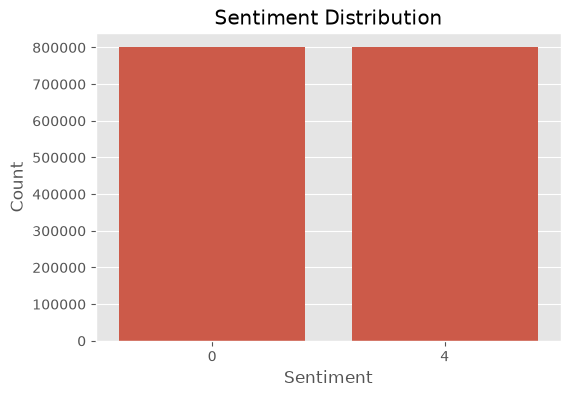

In [7]:
# ==========================================
# Sentiment Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [8]:
# ==========================================
# Convert Labels
# ==========================================

df["Sentiment"] = df["Sentiment"].replace({
    0: "Negative",
    4: "Positive"
})

df.head()

,Sentiment,ID,Date,Query,User,Tweet
0,Negative,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,Negative,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,Negative,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,Negative,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


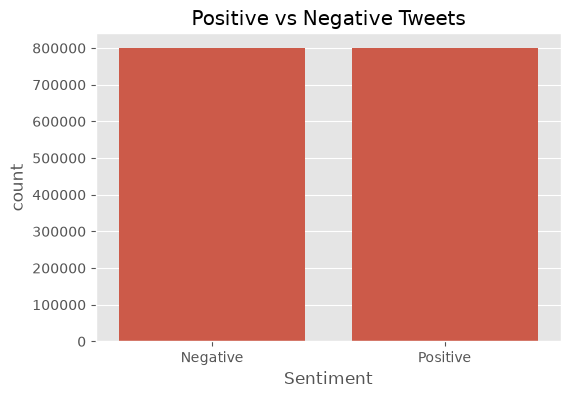

In [9]:
# ==========================================
# Updated Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sentiment")

plt.title("Positive vs Negative Tweets")

plt.show()

In [10]:
# ==========================================
# Text Cleaning Function
# ==========================================

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)          # Remove URLs
    text = re.sub(r"@\w+", "", text)             # Remove Mentions
    text = re.sub(r"#\w+", "", text)             # Remove Hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text)      # Remove Numbers & Punctuation
    text = re.sub(r"\s+", " ", text).strip()     # Remove Extra Spaces
    return text

df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

print("Text Cleaning Completed Successfully")

df[["Tweet","Clean_Tweet"]].head()

Text Cleaning Completed Successfully


,Tweet,Clean_Tweet
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


In [12]:
# ==========================================
# Calculate Polarity (Sample Data)
# ==========================================

# Take only first 10,000 tweets
sample_df = df.sample(10000, random_state=42).copy()

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

sample_df["Polarity"] = sample_df["Clean_Tweet"].apply(get_polarity)

print("Polarity Calculation Completed")
sample_df.head()

Polarity Calculation Completed


,Sentiment,ID,Date,Query,User,Tweet,Clean_Tweet,Polarity
541200,Negative,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh i hope your ok,0.50
750,Negative,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo...",cool i have no tweet apps for my razr,0.35
766711,Negative,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...,i know just family drama its lamehey next time...,-0.25
285055,Negative,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...,school email wont open and i have geography st...,-0.40
705995,Negative,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem,upper airways problem,0.00


In [13]:
# ==========================================
# Predict Sentiment
# ==========================================

def predict_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

sample_df["Predicted_Sentiment"] = sample_df["Polarity"].apply(predict_sentiment)

sample_df.head()

,Sentiment,ID,Date,Query,User,Tweet,Clean_Tweet,Polarity,Predicted_Sentiment
541200,Negative,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh i hope your ok,0.50,Positive
750,Negative,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo...",cool i have no tweet apps for my razr,0.35,Positive
766711,Negative,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...,i know just family drama its lamehey next time...,-0.25,Negative
285055,Negative,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...,school email wont open and i have geography st...,-0.40,Negative
705995,Negative,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem,upper airways problem,0.00,Neutral


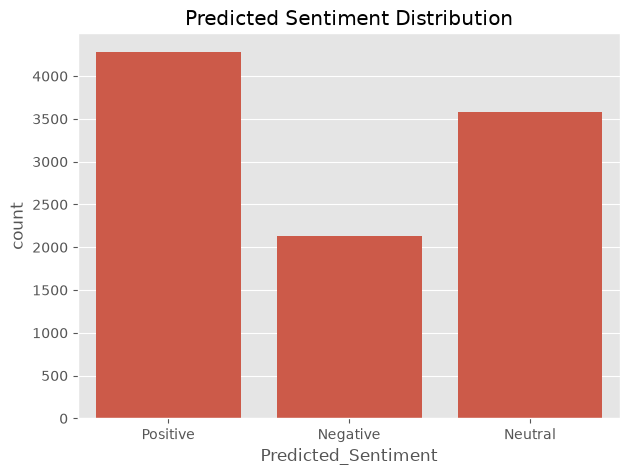

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(data=sample_df, x="Predicted_Sentiment")

plt.title("Predicted Sentiment Distribution")

plt.show()

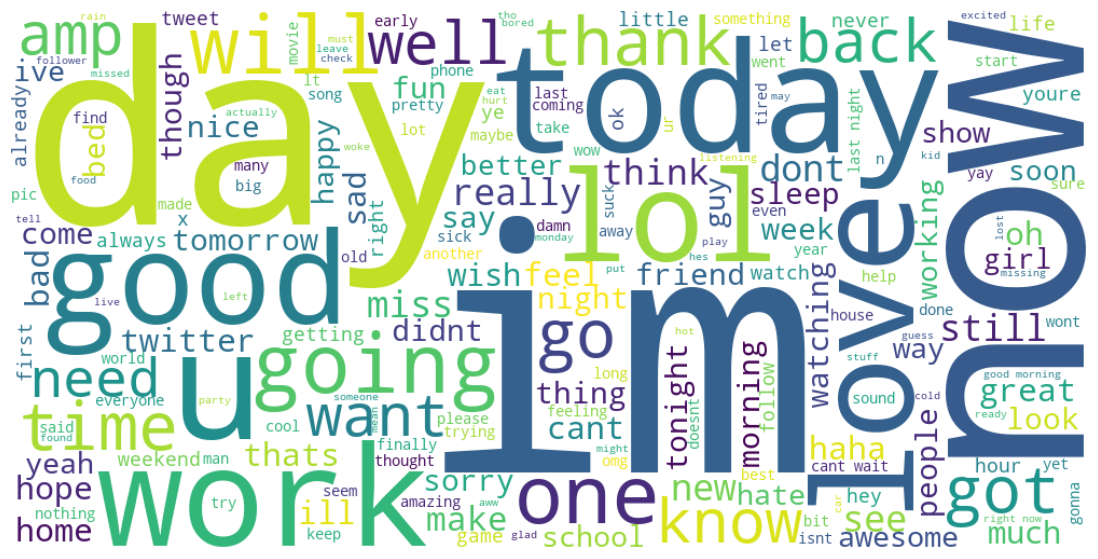

In [15]:
from wordcloud import WordCloud

text = " ".join(sample_df["Clean_Tweet"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [16]:
# ==========================================
# Conclusion
# ==========================================

print("=" * 50)
print("      Sentiment Analysis Completed")
print("=" * 50)

print("\nProject Summary:")
print("- Dataset Loaded Successfully")
print("- Data Cleaned Successfully")
print("- Missing Values Checked")
print("- Sentiment Distribution Visualized")
print("- Tweets Cleaned")
print("- Polarity Calculated using TextBlob")
print("- Sentiment Predicted")
print("- WordCloud Generated")

print("\nCodeAlpha Sentiment Analysis Project Completed Successfully!")

      Sentiment Analysis Completed

Project Summary:
- Dataset Loaded Successfully
- Data Cleaned Successfully
- Missing Values Checked
- Sentiment Distribution Visualized
- Tweets Cleaned
- Polarity Calculated using TextBlob
- Sentiment Predicted
- WordCloud Generated

CodeAlpha Sentiment Analysis Project Completed Successfully!
